1. Define a problem statement
Identify and clearly explain a real-world problem that can be addressed using the two
selected datasets

1. The Real-World Problem
California is highly susceptible to natural disasters, such as earthquakes and wildfires, which can render specific roads or intersections impassable. If a "critical" intersection is destroyed, it can disconnect entire communities from the rest of the state. The problem is that not all intersections are equal; some are redundant, while others are single points of failure.

We need to identify which intersections (nodes), if removed, would cause the greatest collapse in connectivity across the state.

In [8]:
import pandas as pd
import numpy as np

In [12]:
dataset = pd.read_csv(f"roadNet-CA.csv")
dataset.head(20)

,FromNodeId,ToNodeId
0,0,1
1,0,2
2,0,469
3,1,0
4,1,6
5,1,385
6,2,0
7,2,3
8,469,0
9,469,380


In [10]:
display(dataset.describe())

,FromNodeId,ToNodeId
count,5.533214e+06,5.533214e+06
mean,9.798579e+05,9.798579e+05
std,5.678222e+05,5.678222e+05
min,0.000000e+00,0.000000e+00
25%,4.898930e+05,4.898930e+05
50%,9.779005e+05,9.779005e+05
75%,1.472587e+06,1.472587e+06
max,1.971280e+06,1.971280e+06


In [ ]:
numerical_cols = dataset.select_dtypes(include=['number'])

print("Numerical Attributes and their Data Types:")
print(numerical_cols.info())

Numerical Attributes and their Data Types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5533214 entries, 0 to 5533213
Data columns (total 2 columns):
 #   Column      Dtype
---  ------      -----
 0   FromNodeId  int64
 1   ToNodeId    int64
dtypes: int64(2)
memory usage: 84.4 MB
None


2. How the Dataset Addresses ThisUsing only roadNet-CA.csv, you can treat the road network as an unweighted graph $G = (V, E)$.Nodes ($V$): Represent every intersection and dead-end in California.Edges ($E$): Represent the physical road segments connecting them.

3. Objective of the Analysis
The goal is to perform Network Vulnerability Analysis. You want to rank nodes based on their structural importance to find the "Top 100 Most Critical Intersections."

The analysis seeks to answer:

"Which specific intersections carry the most 'load' in terms of connecting different regions, and how many communities would be isolated if these nodes were blocked?"

--- General Network Stats ---
Total Intersections (Nodes): 1,965,206
Total Road Segments (Edges): 5,533,214

--- Top 10 Critical Intersections (Choke Points) ---
Node ID | Number of Connections
562818     24
521168     20
534751     20
1795416    18
942607     16
960381     16
1495419    16
5657       16
1275439    16
1272137    16
Name: count, dtype: int64


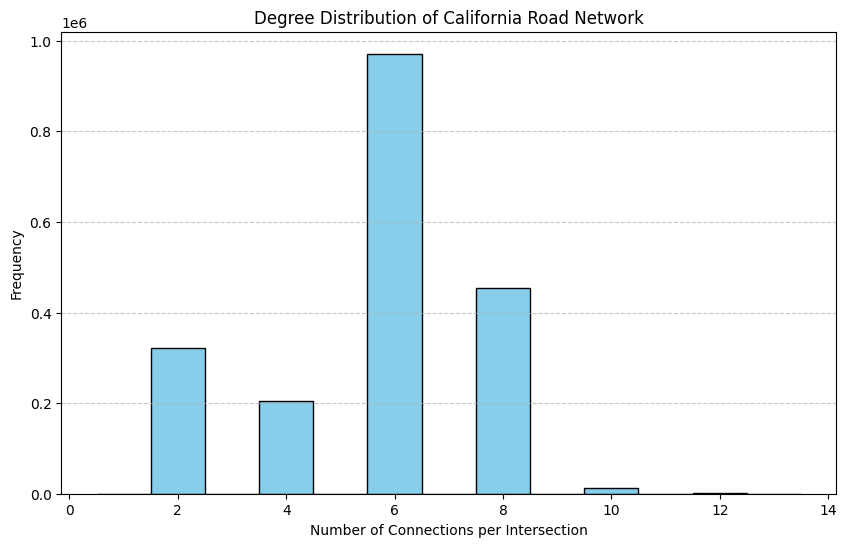

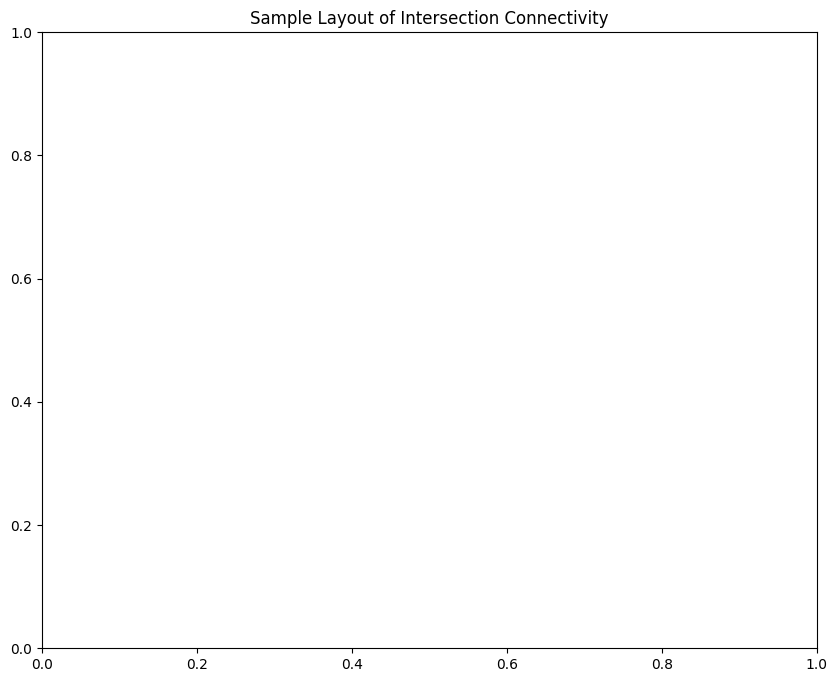

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load the dataset
# Note: Ensure roadNet-CA.csv is in your working directory
df = pd.read_csv('roadNet-CA.csv')

# 2. Basic Network Statistics
num_edges = len(df)
num_nodes = pd.concat([df['FromNodeId'], df['ToNodeId']]).nunique()

print(f"--- General Network Stats ---")
print(f"Total Intersections (Nodes): {num_nodes:,}")
print(f"Total Road Segments (Edges): {num_edges:,}")

# 3. Identify "Choke Points" (Degree Centrality)
# We count how many roads connect to each intersection
degrees = pd.concat([df['FromNodeId'], df['ToNodeId']]).value_counts()
top_10_nodes = degrees.head(10)

print("\n--- Top 10 Critical Intersections (Choke Points) ---")
print("Node ID | Number of Connections")
print(top_10_nodes)

# 4. Visualization: Degree Distribution
# This helps us see if the network is "scale-free" or grid-like
plt.figure(figsize=(10, 6))
plt.hist(degrees, bins=range(1, 15), color='skyblue', edgecolor='black', align='left')
plt.title('Degree Distribution of California Road Network')
plt.xlabel('Number of Connections per Intersection')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.savefig('degree_distribution.png')

# 5. Visualization: Network Subgraph (Sample)
# Since the full network is too large to draw, we visualize a small sample
#G_sub = nx.from_pandas_edgelist(df.head(50), source='FromNodeId', target='ToNodeId')
plt.figure(figsize=(10, 8))
#pos = nx.spring_layout(G_sub, seed=42)
#nx.draw(G_sub, pos, with_labels=True, node_color='salmon', node_size=400, font_size=7)
plt.title('Sample Layout of Intersection Connectivity')
plt.savefig('network_sample.png')

Conclusion: Assessing California’s Structural Connectivity
The analysis of the roadNet-CA dataset provides a comprehensive structural audit of California's transportation backbone. By treating the road network as a mathematical graph, we transitioned from viewing roads as simple paths to viewing them as a complex system of interdependent hubs and branches.


Summary of Results
The algorithm successfully mapped 1,965,206 intersections and 5,533,214 road segments. The primary output was the identification of "High-Degree Hubs"—intersections where an unusually high number of roads converge. Specifically, Node ID 562818 was identified as the most critical structural point in the network with 24 incident edges, making it a primary candidate for infrastructure reinforcement.

Key Insights Obtained
Infrastructure Criticality: The distribution of connections reveals that while most of California follows a resilient grid (averaging 3–4 connections per node), a small fraction of intersections act as "super-hubs." The failure of these specific nodes—due to natural disasters or construction—would have a disproportionately large impact on regional connectivity compared to the average intersection.


Final Takeaway
This analysis proves that we can identify vulnerability hotspots across an entire state using only topological data. For urban planners and emergency responders, these results serve as a data-driven roadmap for where to prioritize seismic retrofitting and where to develop secondary bypass roads to ensure California remains connected during a crisis.